In [2]:
import os

os.chdir('/content/drive/MyDrive/02740_data/line_curve_detection')

#### Hough Line Transformation

The Hough Line Transformation is a feature extraction technique used in image analysis to detect straight lines. It works by transforming points in an image to the Hough space and identifying lines through parameter space.

The Hough Transform algorithm for line detection follows these steps:

1. **Edge Detection**: Detect edges in the image using an edge detection method (e.g., Canny).
2. **Parameterization**: For each edge point $(x, y)$, transform it into the Hough space by calculating potential lines using the equation $d = x \cos(\theta) + y \sin(\theta)$, where $d$ is the perpendicular distance from the origin and $\theta$ is the angle.
3. **Vote Accumulation**: In Hough space, increment the accumulator (a 2D array) for each pair of $(\theta, d)$ values that describe a line passing through the edge point.
4. **Peak Detection**: Identify peaks in the accumulator, which correspond to the most likely lines in the original image.
5. **Line Extraction**: Retrieve the lines in the image based on the $(\theta, d)$ values at the accumulator's peaks.


In [ ]:
# Adapted from skimage tutorial: https://scikit-image.org/docs/stable/auto_examples/edges/plot_line_hough_transform.html

import numpy as np

from skimage.transform import hough_line, hough_line_peaks
from skimage.feature import canny
from skimage.draw import line as draw_line
from skimage import data

import matplotlib.pyplot as plt
from matplotlib import cm


# Constructing test image
image = np.zeros((200, 200))
idx = np.arange(25, 175)
image[idx, idx] = 255
image[draw_line(45, 25, 25, 175)] = 255
image[draw_line(25, 135, 175, 155)] = 255

# Classic straight-line Hough transform
# Set a precision of 0.5 degree.
tested_angles = np.linspace(-np.pi / 2, np.pi / 2, 360, endpoint=False)

h, theta, d = hough_line(image, theta=tested_angles)

# Generating figure 1
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
ax = axes.ravel()

ax[0].imshow(image, cmap=cm.gray)
ax[0].set_title('Input image')
ax[0].set_axis_off()

angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [
    np.rad2deg(theta[0] - angle_step),
    np.rad2deg(theta[-1] + angle_step),
    d[-1] + d_step,
    d[0] - d_step,
]
ax[1].imshow(np.log(1 + h), extent=bounds, cmap=cm.gray, aspect='auto')
ax[1].set_title('Hough transform')
ax[1].set_xlabel('Angles (degrees)')
ax[1].set_ylabel('Distance (pixels)')
ax[1].axis('image')

ax[2].imshow(image, cmap=cm.gray)
ax[2].set_ylim((image.shape[0], 0))
ax[2].set_axis_off()
ax[2].set_title('Detected lines')

for _, angle, dist in zip(*hough_line_peaks(h, theta, d)):
    (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
    ax[2].axline((x0, y0), slope=np.tan(angle + np.pi / 2))

plt.tight_layout()
plt.show()

### Apply Hough Transform to Bioimages


In [ ]:
import cv2

img = cv2.imread('smooth_muscle.jpg')

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = canny(img)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])

plt.show()


In [ ]:
out, angles, d = hough_line(edges)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(edges, cmap=plt.cm.gray)
axes[0].set_title('Input image')

axes[1].imshow(
    out, cmap=plt.cm.bone,
    extent=(np.rad2deg(angles[-1]), np.rad2deg(angles[0]), d[-1], d[0]), aspect='auto'
)
axes[1].set_title('Hough transform')
axes[1].set_xlabel('Angle (degree)')
axes[1].set_ylabel('Distance (pixel)')

plt.tight_layout()
plt.show()


In [ ]:
plt.imshow(img, cmap=cm.gray)
plt.title('Detected lines')
plt.axis('off')

for _, angle, dist in zip(*hough_line_peaks(out, angles, d, num_peaks = 10)):
    (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
    plt.axline((x0, y0), slope=np.tan(angle + np.pi / 2))

plt.show()

In [ ]:
_, otsu_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(255-otsu_thresh, cmap='gray')
plt.title("Otsu's Binarization")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
out, angles, d = hough_line(255-otsu_thresh)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(255-otsu_thresh, cmap=plt.cm.gray)
axes[0].set_title('Input image')

axes[1].imshow(
    out, cmap=plt.cm.bone,
    extent=(np.rad2deg(angles[-1]), np.rad2deg(angles[0]), d[-1], d[0]), aspect='auto'
)
axes[1].set_title('Hough transform')
axes[1].set_xlabel('Angle (degree)')
axes[1].set_ylabel('Distance (pixel)')

plt.tight_layout()
plt.show()


In [ ]:
plt.imshow(img, cmap=cm.gray)
plt.title('Detected lines')
plt.axis('off')

for _, angle, dist in zip(*hough_line_peaks(out, angles, d, num_peaks = 10)):
    (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
    plt.axline((x0, y0), slope=np.tan(angle + np.pi / 2))

plt.show()

In [ ]:
image = 255-otsu_thresh

# Apply opening to remove noisy regions
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
opened_image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(10, 4))
plt.imshow(opened_image, cmap='gray')
plt.title('Opened Image')
plt.axis('off')
plt.show()

In [ ]:
out, angles, d = hough_line(opened_image)
plt.imshow(img, cmap=cm.gray)
plt.title('Detected lines')
plt.axis('off')

for _, angle, dist in zip(*hough_line_peaks(out, angles, d, num_peaks = 10)):
    (x0, y0) = dist * np.array([np.cos(angle), np.sin(angle)])
    plt.axline((x0, y0), slope=np.tan(angle + np.pi / 2))

plt.show()

### Probabilistic Hough Transform for Line Detection

The Probabilistic Hough Transform (PHT) algorithm for line detection follows these steps:

1. **Edge Detection**: Detect edges in the image using an edge detection method (e.g., Canny).
2. **Random Sampling**: Randomly select a subset of edge points, rather than considering all points, to reduce computational cost.
3. **Parameterization**: For each sampled edge point $(x, y)$, calculate potential lines using the equation $d = x \cos(\theta) + y \sin(\theta)$, where $d$ is the perpendicular distance from the origin and $\theta$ is the angle.
4. **Line Segment Detection**: Instead of accumulating votes for all points along a potential line, detect line segments by iteratively checking for collinear points.
5. **Line Extraction**: Directly obtain the endpoints of the detected line segments, which can be immediately used without needing to analyze peaks in an accumulator.



In [ ]:
# Image of cell wall synthesis
img = cv2.imread('cell_wall.jpg')
plt.imshow(img)
plt.show()

In [ ]:
from skimage.transform import probabilistic_hough_line

# Line finding using the Probabilistic Hough Transform
img = cv2.imread('cell_wall.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = canny(img)

# Two settings for line lengths
lines = probabilistic_hough_line(edges, threshold=10, line_length=5, line_gap=3)
lines_2 = probabilistic_hough_line(edges, threshold=10, line_length=10, line_gap=3)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(img, cmap=cm.gray)
ax[0].set_title('Input image')

ax[1].imshow(edges, cmap=cm.gray)
ax[1].set_title('Canny edges')

ax[2].imshow(edges * 0)
for line in lines:
    p0, p1 = line
    ax[2].plot((p0[0], p1[0]), (p0[1], p1[1]))
ax[2].set_xlim((0, img.shape[1]))
ax[2].set_ylim((img.shape[0], 0))
ax[2].set_title('Probabilistic Hough, length = 5')

ax[3].imshow(edges * 0)
for line in lines_2:
    p0, p1 = line
    ax[3].plot((p0[0], p1[0]), (p0[1], p1[1]))
ax[3].set_xlim((0, img.shape[1]))
ax[3].set_ylim((img.shape[0], 0))
ax[3].set_title('Probabilistic Hough, length = 10')

for a in ax:
    a.set_axis_off()

plt.tight_layout()
plt.show()

### Hough Transform for Circle Detection

The Hough Transform algorithm for circle detection follows these steps:

1. **Edge Detection**: Detect edges in the image using an edge detection method (e.g., Canny).
2. **Parameterization**: For each edge point $(x, y)$, transform it into the Hough space by calculating potential circles. A circle is parameterized by its center $(a, b)$ and radius $r$, using the equation $(x - a)^2 + (y - b)^2 = r^2$.
3. **Vote Accumulation**: For each edge point and radius, increment the accumulator (a 3D array) for the possible center coordinates $(a, b)$ by solving the circle equation.
4. **Peak Detection**: Identify peaks in the accumulator, which correspond to the most likely circle centers and radii in the original image.
5. **Circle Extraction**: Retrieve the circles in the image based on the $(a, b, r)$ values at the accumulator's peaks.

In [ ]:
# Load picture and detect edges

image = cv2.imread("blood_cell.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image, cmap='gray')
plt.show()
edges = canny(image, sigma=1e-5)
plt.imshow(edges, cmap='gray')
plt.show()

In [ ]:
# Adapted from the skimage tutorial: https://scikit-image.org/docs/stable/auto_examples/edges/plot_circular_elliptical_hough_transform.html

import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.feature import canny
from skimage.draw import circle_perimeter


# Detect 8 radii
hough_radii = np.arange(50, 120, 8)
hough_res = hough_circle(edges, hough_radii)

# Select the most prominent 10 circles
accums, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=10, min_xdistance=100, min_ydistance=100)

# Draw them
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 4))
image = color.gray2rgb(image)
for center_y, center_x, radius in zip(cy, cx, radii):
    circy, circx = circle_perimeter(center_y, center_x, radius, shape=image.shape)
    image[circy, circx] = (220, 20, 20)

ax.imshow(image, cmap=plt.cm.gray)
plt.show()

### Steger's Line Algorithm
Steger's algorithm is used for detecting curvilinear structures, like lines or edges, in an image with sub-pixel accuracy. The algorithm involves computing the first and second derivatives of the image intensity to find the direction and curvature of edges or lines.

**Detailed Explanation:**

- Given the standard deviation of the Gaussian, we calculate the filter size. The filter size is typically set to encompass the significant area around each pixel influenced by the Gaussian. Additionally, a threshold value is set to identify significant edges, allowing us to filter out low-intensity pixels.

- Iterate over the image pixels, ensuring to stay within the boundary defined by the filter size. For each pixel, compare its intensity against the defined threshold value.

- For pixels exceeding the threshold value, select a sub-region around each of these pixels. This sub-region is centered on the pixel and has dimensions based on the filter size. These sub-regions are used to calculate the gradients and second derivatives.

- The second derivatives are then used to construct Hessian Matrix. Eigen Values and Eigen Vectors are calculated for the Hessian matrix. The eigenvalues give the principal curvatures, and the eigenvectors indicate the directions of these curvatures.

- Select the eigenvector associated with the largest absolute eigenvalue as the dominant direction. Calculate the curvature t using the direction components (nx, ny) and the gradients (gx, gy).

- If the curvature t satisfies specific conditions, mark the pixel as an edge in the output image. Additionally, set the corresponding pixel in the original image to zero. These conditions ensure that only significant and relevant edges are detected.

### Local Curvature
Local curvature measures how sharply a curve bends at a particular point. It is an important concept in differential geometry and can be calculated using the first and second derivatives of a function.

Below is a sample code demonstrating how to compute the local curvature of a function:
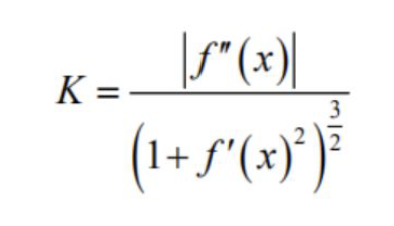

In [ ]:
def f(x):
    return x**3 + 3*(x**2)

def first_derivative(x):
    return 3*(x**2)+6*x

def second_derivative(x):
    return 6*x+6

def curvature(x):
    k1 = abs(second_derivative(x))
    k2 = (1+first_derivative(x)**2)**(3/2)

    return k1/k2

x = -2

print("f(x)=", f(x))
print("f'(x)=", first_derivative(x))
print("f''(x)=", second_derivative(x))
print("curvature =", curvature(x))

#### First Order Directional Derivative
The first-order directional derivative of a function measures the rate at which the function changes as we move in a specified direction. It combines the partial derivatives of the function with the direction vector.

Below is a sample code demonstrating how to compute the first-order directional derivative:

In [ ]:
import math
def f(x, y):
    return x**2 + 4*y

def derivative(x, y):
    dfx = 2*x
    dfy = 4
    return dfx, dfy

def first_order_derivative(x, y, beta):
    sin = math.sin(beta)
    cos = math.cos(beta)
    dfx, dfy = derivative(x, y)

    return sin*dfx + cos*dfy

x = 2
y = 1
beta = math.pi / 3
print("f(x,y) = ", f(x,y))
print("first order derivative = ", first_order_derivative(x, y, beta))

#### Second Order Directional Derivative


The second-order directional derivative of a function measures the rate at which the first-order directional derivative changes in a specified direction. It involves the Hessian matrix, which contains the second partial derivatives of the function.

Below is a sample code demonstrating how to compute the second-order directional derivative:


In [ ]:
import numpy as np
import math

def f(x, y):
    return x**2 + 2 * y**3 + x * y

def dfx2(x, y):
    return 2

def dfxfy(x, y):
    return 1

def dfyfx(x, y):
    return 1

def dfy2(x, y):
    return 6

def Hessian(x, y):
    return np.array([[dfx2(x, y), dfxfy(x, y)], [dfyfx(x, y), dfy2(x, y)]])

def second_directional_derivative(x, y, beta):
    hessian = Hessian(x, y)
    sin = math.sin(beta)
    cos = math.cos(beta)
    return (np.array([sin, cos]).dot(hessian)).dot(np.array([sin, cos]))

x = 2
y = 1
beta = math.pi / 3
print("f(x,y)=", f(x, y))
print("Hessian=", Hessian(x, y))
print("second_directional_derivative=", second_directional_derivative(x, y, beta))


In [ ]:
import numpy as np
import math
from matplotlib import pyplot
import matplotlib.pyplot as plt


def hx(zita, m):
    h = np.zeros((2*m+1, 2*m+1))
    for i in range(-m, m+1):
        for j in range(-m, m+1):
            h[i+m, j+m] = -(j)/(zita**2) * 1/(2*math.pi*zita**2) * math.exp(-(i**2+j**2) / (2*zita**2))
    return h

def hxx(zita, m):
    h = np.zeros((2*m+1, 2*m+1))
    for i in range(-m, m+1):
        for j in range(-m, m+1):
            h[i+m, j+m] = (j**2 / zita**4 - 1/zita**2) * 1/(2*math.pi*zita**2) * math.exp(-(i**2+j**2) / (2*zita**2))
    return h

def hxy(zita, m):
    h = np.zeros((2*m+1, 2*m+1))
    for i in range(-m, m+1):
        for j in range(-m, m+1):
            h[i+m, j+m] = -(i*j) / zita**4 * 1/(2*math.pi*zita**2) * math.exp(-(i**2+j**2) / (2*zita**2))
    return h

def hy(zita, m):
    h = np.zeros((2*m+1, 2*m+1))
    for i in range(-m, m+1):
        for j in range(-m, m+1):
            h[i+m, j+m] = -(i)/(zita**2) * 1/(2*math.pi*zita**2) * math.exp(-(i**2+j**2) / (2*zita**2))
    return h

def hyy(zita, m):
    h = np.zeros((2*m+1, 2*m+1))
    for i in range(-m, m+1):
        for j in range(-m, m+1):
            h[i+m, j+m] = (i**2 / zita**4 - 1/zita**2) * 1/(2*math.pi*zita**2) * math.exp(-(i**2+j**2) / (2*zita**2))
    return h

imagedata = cv2.imread('cell_wall.jpg')
imagedata = cv2.cvtColor(imagedata, cv2.COLOR_BGR2GRAY)
imagedata = cv2.resize(imagedata, (200,200))
ori_m = np.array(imagedata)
ori_or = np.array(imagedata)
ori = ori_m.astype(np.float32)
zita = 5 / math.sqrt(3)
h_size = 2 * math.ceil(3 * zita - 1) + 1
h_N1 = int((h_size - 1) / 2)
height, width = ori.shape
image_1 = np.zeros((height, width))
yuzhil = 50
ftt_max2 = -1

for i in range(h_N1, height - h_N1):
    for j in range(h_N1, width - h_N1):
        if ori[i, j] > yuzhil:
            ori_l = ori[i-h_N1:i+h_N1+1, j-h_N1:j+h_N1+1]
            gx = np.sum(np.sum(ori_l * hx(zita, h_N1)))
            gy = np.sum(np.sum(ori_l * hy(zita, h_N1)))
            gxx = np.sum(np.sum(ori_l * hxx(zita, h_N1)))
            gyy = np.sum(np.sum(ori_l * hyy(zita, h_N1)))
            gxy = np.sum(np.sum(ori_l * hxy(zita, h_N1)))
            V, D = np.linalg.eig([[gxx, gxy], [gxy, gyy]])
            if abs(V[0]) >= abs(V[1]):
                nx_ny = D[:, 0]
                fttmax = V[0]
            else:
                nx_ny = D[:, 1]
                fttmax = V[1]
            nx = nx_ny[0]
            ny = nx_ny[1]
            t = (nx * gx + ny * gy) / ((nx**2) * gxx + 2 * nx * ny * gxy + (ny**2) * gyy)

            # The conditions abs(t * nx) <= 0.5 and abs(t * ny) <= 0.5 ensure that
            # the pixel lies close to the salient feature, based on the estimated normal direction.

            if (abs(t * nx) <= 0.5) and (abs(t * ny) <= 0.5) and (fttmax < ftt_max2):
                image_1[i, j] = 255
                ori_m[i, j] = 0

plt.figure(figsize = (15,5))
plt.subplot(131)
plt.imshow(ori_or, cmap = 'gray')
plt.title('image_1')
plt.subplot(132)
plt.imshow(image_1, cmap = 'gray')
plt.title('image_2')
plt.subplot(133)
plt.imshow(ori_m, cmap = 'gray')
plt.title('image_3')
plt.show()


In [ ]:
# Steger algorithm for edge/line extraction
# Author : Munch Quentin, 2020

"""
This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.
This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.
You should have received a copy of the GNU General Public License
along with this program.  If not, see <https://www.gnu.org/licenses/>.
"""

# General and computer vision lib
import numpy as np
import cv2
from matplotlib import pyplot as plt
from matplotlib import pyplot

def computeDerivative(img, sigmaX, sigmaY):
    # blurr the image
    img = cv2.GaussianBlur(img, ksize=(0,0), sigmaX=sigmaX, sigmaY=sigmaY)
    # create filter for derivative calulation
    dxFilter = np.array([[1],[0],[-1]])
    dyFilter = np.array([[1,0,-1]])
    dxxFilter = np.array([[1],[-2],[1]])
    dyyFilter = np.array([[1,-2,1]])
    dxyFilter = np.array([[1,-1],[-1,1]])
    # compute derivative
    dx = cv2.filter2D(img,-1, dxFilter)
    dy = cv2.filter2D(img,-1, dyFilter)
    dxx = cv2.filter2D(img,-1, dxxFilter)
    dyy = cv2.filter2D(img,-1, dyyFilter)
    dxy = cv2.filter2D(img,-1, dxyFilter)
    return dx, dy, dxx, dyy, dxy

def computeMagnitude(dxx, dyy):
    # convert to float
    dxx = dxx.astype(float)
    dyy = dyy.astype(float)
    # calculate magnitude and angle
    mag = cv2.magnitude(dxx, dyy)
    phase = mag*180./np.pi
    return mag, phase

def computeHessian(dx, dy, dxx, dyy, dxy):
    # create empty list
    point=[]
    direction=[]
    value=[]
    # for the all image
    for x in range(0, img.shape[1]): # column
        for y in range(0, img.shape[0]): # line
            # if superior to certain threshold
            if dxy[y,x] > 1:
                # compute local hessian
                hessian = np.zeros((2,2))
                hessian[0,0] = dxx[y,x]
                hessian[0,1] = dxy[y,x]
                hessian[1,0] = dxy[y,x]
                hessian[1,1] = dyy[y,x]
                # compute eigen vector and eigen value
                ret, eigenVal, eigenVect = cv2.eigen(hessian)
                if np.abs(eigenVal[0,0]) >= np.abs(eigenVal[1,0]):
                    nx = eigenVect[0,0]
                    ny = eigenVect[0,1]
                else:
                    nx = eigenVect[1,0]
                    ny = eigenVect[1,1]
                # calculate denominator for the taylor polynomial expension
                denom = dxx[y,x]*nx*nx + dyy[y,x]*ny*ny + 2*dxy[y,x]*nx*ny
                # verify non zero denom
                if denom != 0:
                    T = -(dx[y,x]*nx + dy[y,x]*ny)/denom
                    # update point
                    if np.abs(T*nx) <= 0.5 and np.abs(T*ny) <= 0.5:
                        point.append((x,y))
                        direction.append((nx,ny))
                        value.append(np.abs(dxy[y,x]+dxy[y,x]))
    return point, direction, value

# resize, grayscale and blurr
img = cv2.imread("cell_wall.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# compute derivative
dx, dy, dxx, dyy, dxy = computeDerivative(gray_img, 1.1, 1.1)
normal, phase = computeMagnitude(dxx, dyy)
pt, dir, val = computeHessian(dx, dy, dxx, dyy, dxy)

# take the first n max value
nMax = 10000
idx = np.argsort(val)
idx = idx[::-1][:nMax]
# plot resulting points
for i in range(0, len(idx)):
    img = cv2.circle(img, (pt[idx[i]][0], pt[idx[i]][1]), 1, (255, 0, 0), 1)
# plot the result
plt.imshow(img)
plt.show()

 #### Histogram Analysis (First Order Statistical Texture)

In [ ]:
# Import necessary libraries
import scipy.stats
import skimage
import scipy
import numpy as np

# Load the camera image and convert it to float
image = cv2.imread('smooth_muscle.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Compute the histogram of the image
histogram, bins = skimage.exposure.histogram(image)

# Calculate the mean of the histogram
mean = np.mean(histogram)

# Calculate the standard deviation of the histogram
standard_deviation = np.std(histogram)

# Calculate the skewness of the histogram
skewness = scipy.stats.skew(histogram)

# Calculate the kurtosis of the histogram
kurtosis = scipy.stats.kurtosis(histogram)

# Calculate the entropy of the histogram
entropy = scipy.stats.entropy(histogram)

# Print the calculated statistical measures
print('Mean:', mean)
print('Standard Deviation:', standard_deviation)
print('Skewness:', skewness)
print('Kurtosis:', kurtosis)
print('Entropy:', entropy)


In [ ]:
plt.hist(image.ravel(), bins=256)
plt.show()